In [9]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Generate Sales Data (The "Messy" File)
np.random.seed(42)
n_sales = 500
regions = ['North', 'South', 'East', 'West']
categories = ['Electronics', 'Accessories', 'Appliances']

sales_data = pd.DataFrame({
    'Transaction_ID': range(1001, 1001 + n_sales),
    'Date': [datetime(2025, 1, 1) + timedelta(days=np.random.randint(0, 90)) for _ in range(n_sales)],
    'Category': np.random.choice(categories, n_sales),
    'Region': np.random.choice(regions, n_sales),
    'Amount': np.random.uniform(500, 5000, n_sales).round(2)
})

# Adding "Dirty" Data for you to clean later:
sales_data.loc[0:10, 'Amount'] = np.nan  # Missing values
sales_data.loc[11:15, 'Region'] = None   # Missing regions
sales_data = pd.concat([sales_data, sales_data.iloc[:5]], ignore_index=True) # Duplicates

# 2. Generate Target Data (The "Clean" Reference)
targets = pd.DataFrame({
    'Month': ['January', 'February', 'March'] * 4,
    'Region': ['North']*3 + ['South']*3 + ['East']*3 + ['West']*3,
    'Target_Amount': [150000, 160000, 170000, 120000, 130000, 140000,
                      100000, 110000, 120000, 180000, 190000, 200000]
})

# Save to CSV
sales_data.to_csv('sales_data.csv', index=False)
targets.to_csv('targets.csv', index=False)

print("Files created: sales_data.csv and targets.csv")

Files created: sales_data.csv and targets.csv


In [10]:
# Load the messy data
df_sales = pd.read_csv('sales_data.csv')

# 1. Remove Duplicates
df_sales = df_sales.drop_duplicates()

# 2. Handle Missing Values
# We'll fill missing 'Amount' with the average and 'Region' with 'Unknown'
df_sales['Amount'] = df_sales['Amount'].fillna(df_sales['Amount'].mean())
df_sales['Region'] = df_sales['Region'].fillna('Unknown')

# 3. Standardize Dates
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales['Month'] = df_sales['Date'].dt.month_name()

print("Data Cleaned! Ready for SQL or Visualization.")
df_sales.head()

Data Cleaned! Ready for SQL or Visualization.


,Transaction_ID,Date,Category,Region,Amount,Month
0,1001,2025-02-21,Electronics,South,2784.583538,February
1,1002,2025-01-15,Appliances,South,2784.583538,January
2,1003,2025-03-13,Accessories,South,2784.583538,March
3,1004,2025-03-02,Accessories,West,2784.583538,March
4,1005,2025-01-21,Electronics,East,2784.583538,January


In [11]:
import sqlite3

# Create a connection to a temporary database
conn = sqlite3.connect('sales_company.db')

# Push our cleaned dataframes into SQL tables
df_sales.to_sql('sales_table', conn, index=False, if_exists='replace')
targets.to_sql('target_table', conn, index=False, if_exists='replace')

print("Database 'sales_company.db' is ready with tables: sales_table, target_table")

Database 'sales_company.db' is ready with tables: sales_table, target_table


In [12]:
query = """
SELECT
    s.Region,
    s.Month,
    SUM(s.Amount) AS Total_Sales,
    t.Target_Amount,
    (SUM(s.Amount) - t.Target_Amount) AS Variance,
    ((SUM(s.Amount) - t.Target_Amount) / t.Target_Amount) * 100 AS Variance_Percentage
FROM sales_table s
JOIN target_table t ON s.Region = t.Region AND s.Month = t.Month
GROUP BY s.Region, s.Month
ORDER BY Variance_Percentage DESC;
"""

# Execute and view the result
variance_report = pd.read_sql_query(query, conn)
variance_report

,Region,Month,Total_Sales,Target_Amount,Variance,Variance_Percentage
0,East,February,141903.910000,110000,31903.910000,29.003555
1,East,January,110771.927076,100000,10771.927076,10.771927
2,South,January,116739.853538,120000,-3260.146462,-2.716789
3,East,March,109877.500000,120000,-10122.500000,-8.435417
4,North,January,131799.750000,150000,-18200.250000,-12.133500
5,South,March,121575.673538,140000,-18424.326462,-13.160233
6,North,February,118447.680000,160000,-41552.320000,-25.970200
7,South,February,92502.923538,130000,-37497.076462,-28.843905
8,West,January,125881.710000,180000,-54118.290000,-30.065717
9,North,March,103914.997076,170000,-66085.002924,-38.873531


In [13]:
query= """
SELECT
    Category,
    SUM(Amount) as Total_Revenue,
    COUNT(Transaction_ID) as Total_Orders,
    AVG(Amount) as Average_Order_Value
FROM sales_table
GROUP BY Category
ORDER BY Total_Revenue DESC;
"""

performing_category = pd.read_sql_query(query, conn)
performing_category

,Category,Total_Revenue,Total_Orders,Average_Order_Value
0,Electronics,509547.840613,181,2815.181440
1,Accessories,466041.144151,162,2876.797186
2,Appliances,416702.784151,157,2654.157861


In [14]:
query = """
SELECT
    Month,
    SUM(Amount) as Current_Month_Sales,
    LAG(SUM(Amount)) OVER (ORDER BY Date) as Previous_Month_Sales,
    (SUM(Amount) - LAG(SUM(Amount)) OVER (ORDER BY Date)) / LAG(SUM(Amount)) OVER (ORDER BY Date) * 100 as Growth_Percentage
FROM sales_table
GROUP BY Month;
"""

monthly_growth = pd.read_sql_query(query, conn)
monthly_growth

,Month,Current_Month_Sales,Previous_Month_Sales,Growth_Percentage
0,January,496503.090613,NaN,NaN
1,February,441121.523538,496503.090613,-11.154325
2,March,454667.154765,441121.523538,3.070726


In [15]:
query = """
SELECT
    s.Region,
    s.Month,
    (SUM(s.Amount) - t.Target_Amount) as Gap
FROM sales_table s
JOIN target_table t ON s.Region = t.Region AND s.Month = t.Month
GROUP BY s.Region, s.Month
HAVING Gap < 0
ORDER BY Gap ASC;
"""

regions_below_target = pd.read_sql_query(query, conn)
regions_below_target

,Region,Month,Gap
0,West,February,-103022.160000
1,West,March,-83085.485849
2,North,March,-66085.002924
3,West,January,-54118.290000
4,North,February,-41552.320000
5,South,February,-37497.076462
6,South,March,-18424.326462
7,North,January,-18200.250000
8,East,March,-10122.500000
9,South,January,-3260.146462


In [16]:
query = """
SELECT
    Transaction_ID,
    Category,
    Amount,
    CASE
        WHEN Amount > (SELECT AVG(Amount) FROM sales_table) * 1.5 THEN 'High Value'
        WHEN Amount > (SELECT AVG(Amount) FROM sales_table) THEN 'Above Average'
        ELSE 'Standard'
    END as Transaction_Segment
FROM sales_table
ORDER BY Amount DESC
LIMIT 10;
"""

high_value_transactions = pd.read_sql_query(query, conn)
high_value_transactions


,Transaction_ID,Category,Amount,Transaction_Segment
0,1116,Electronics,4990.70,High Value
1,1271,Electronics,4987.06,High Value
2,1395,Appliances,4983.50,High Value
3,1166,Appliances,4977.09,High Value
4,1150,Electronics,4960.26,High Value
5,1136,Appliances,4944.75,High Value
6,1073,Electronics,4944.51,High Value
7,1410,Appliances,4944.42,High Value
8,1339,Appliances,4939.98,High Value
9,1486,Accessories,4939.84,High Value


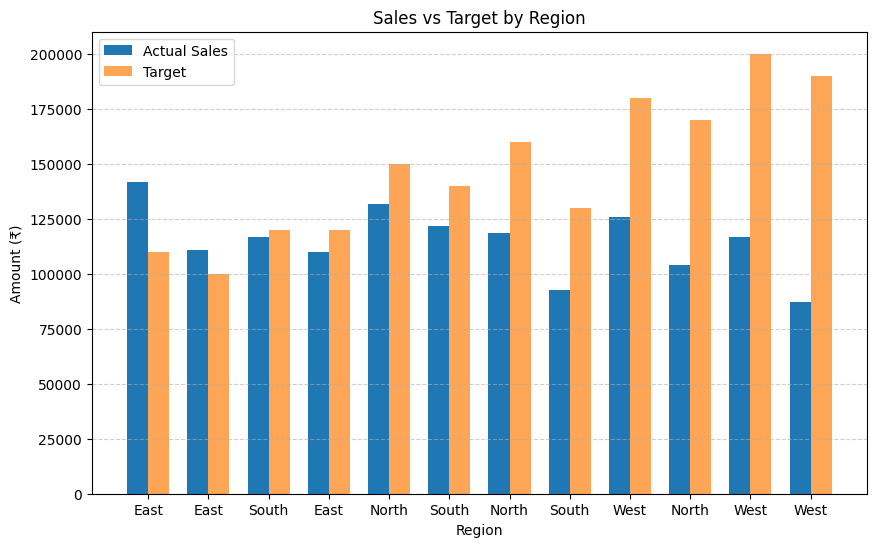

In [17]:
import matplotlib.pyplot as plt

# 1. Prepare Data for Regional Comparison
regional_performance = variance_report[['Region', 'Total_Sales', 'Target_Amount']]

# 2. Plotting
plt.figure(figsize=(10, 6))
x = np.arange(len(regional_performance['Region']))
width = 0.35

plt.bar(x - width/2, regional_performance['Total_Sales'], width, label='Actual Sales', color='#1f77b4')
plt.bar(x + width/2, regional_performance['Target_Amount'], width, label='Target', color='#ff7f0e', alpha=0.7)

plt.xlabel('Region')
plt.ylabel('Amount (₹)')
plt.title('Sales vs Target by Region')
plt.xticks(x, regional_performance['Region'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()